## 25.10.26: KeypointNet

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.classes.pitch import Pitch, PitchKeypointMapping, HomographySolver
from scripts.datasets.calibration import CalibrationDataset, CalibrationLabelsMapping
from scripts.datasets.field_masking import MaskingCalibrationDataset
from scripts.datasets.field_pitch import PitchCalibrationDataset, PitchKeypointCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

WIDTH, HEIGHT = 320, 180

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
calibration_train_dataset = CalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_test_dataset = CalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_valid_dataset = CalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(calibration_train_dataset)}')
print(f'Number of test samples: {len(calibration_test_dataset)}')
print(f'Number of valid samples: {len(calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [3]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [4]:
pitch_keypoint_calibration_train_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_test_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_valid_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(pitch_keypoint_calibration_train_dataset)}')
print(f'Number of test samples: {len(pitch_keypoint_calibration_test_dataset)}')
print(f'Number of valid samples: {len(pitch_keypoint_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


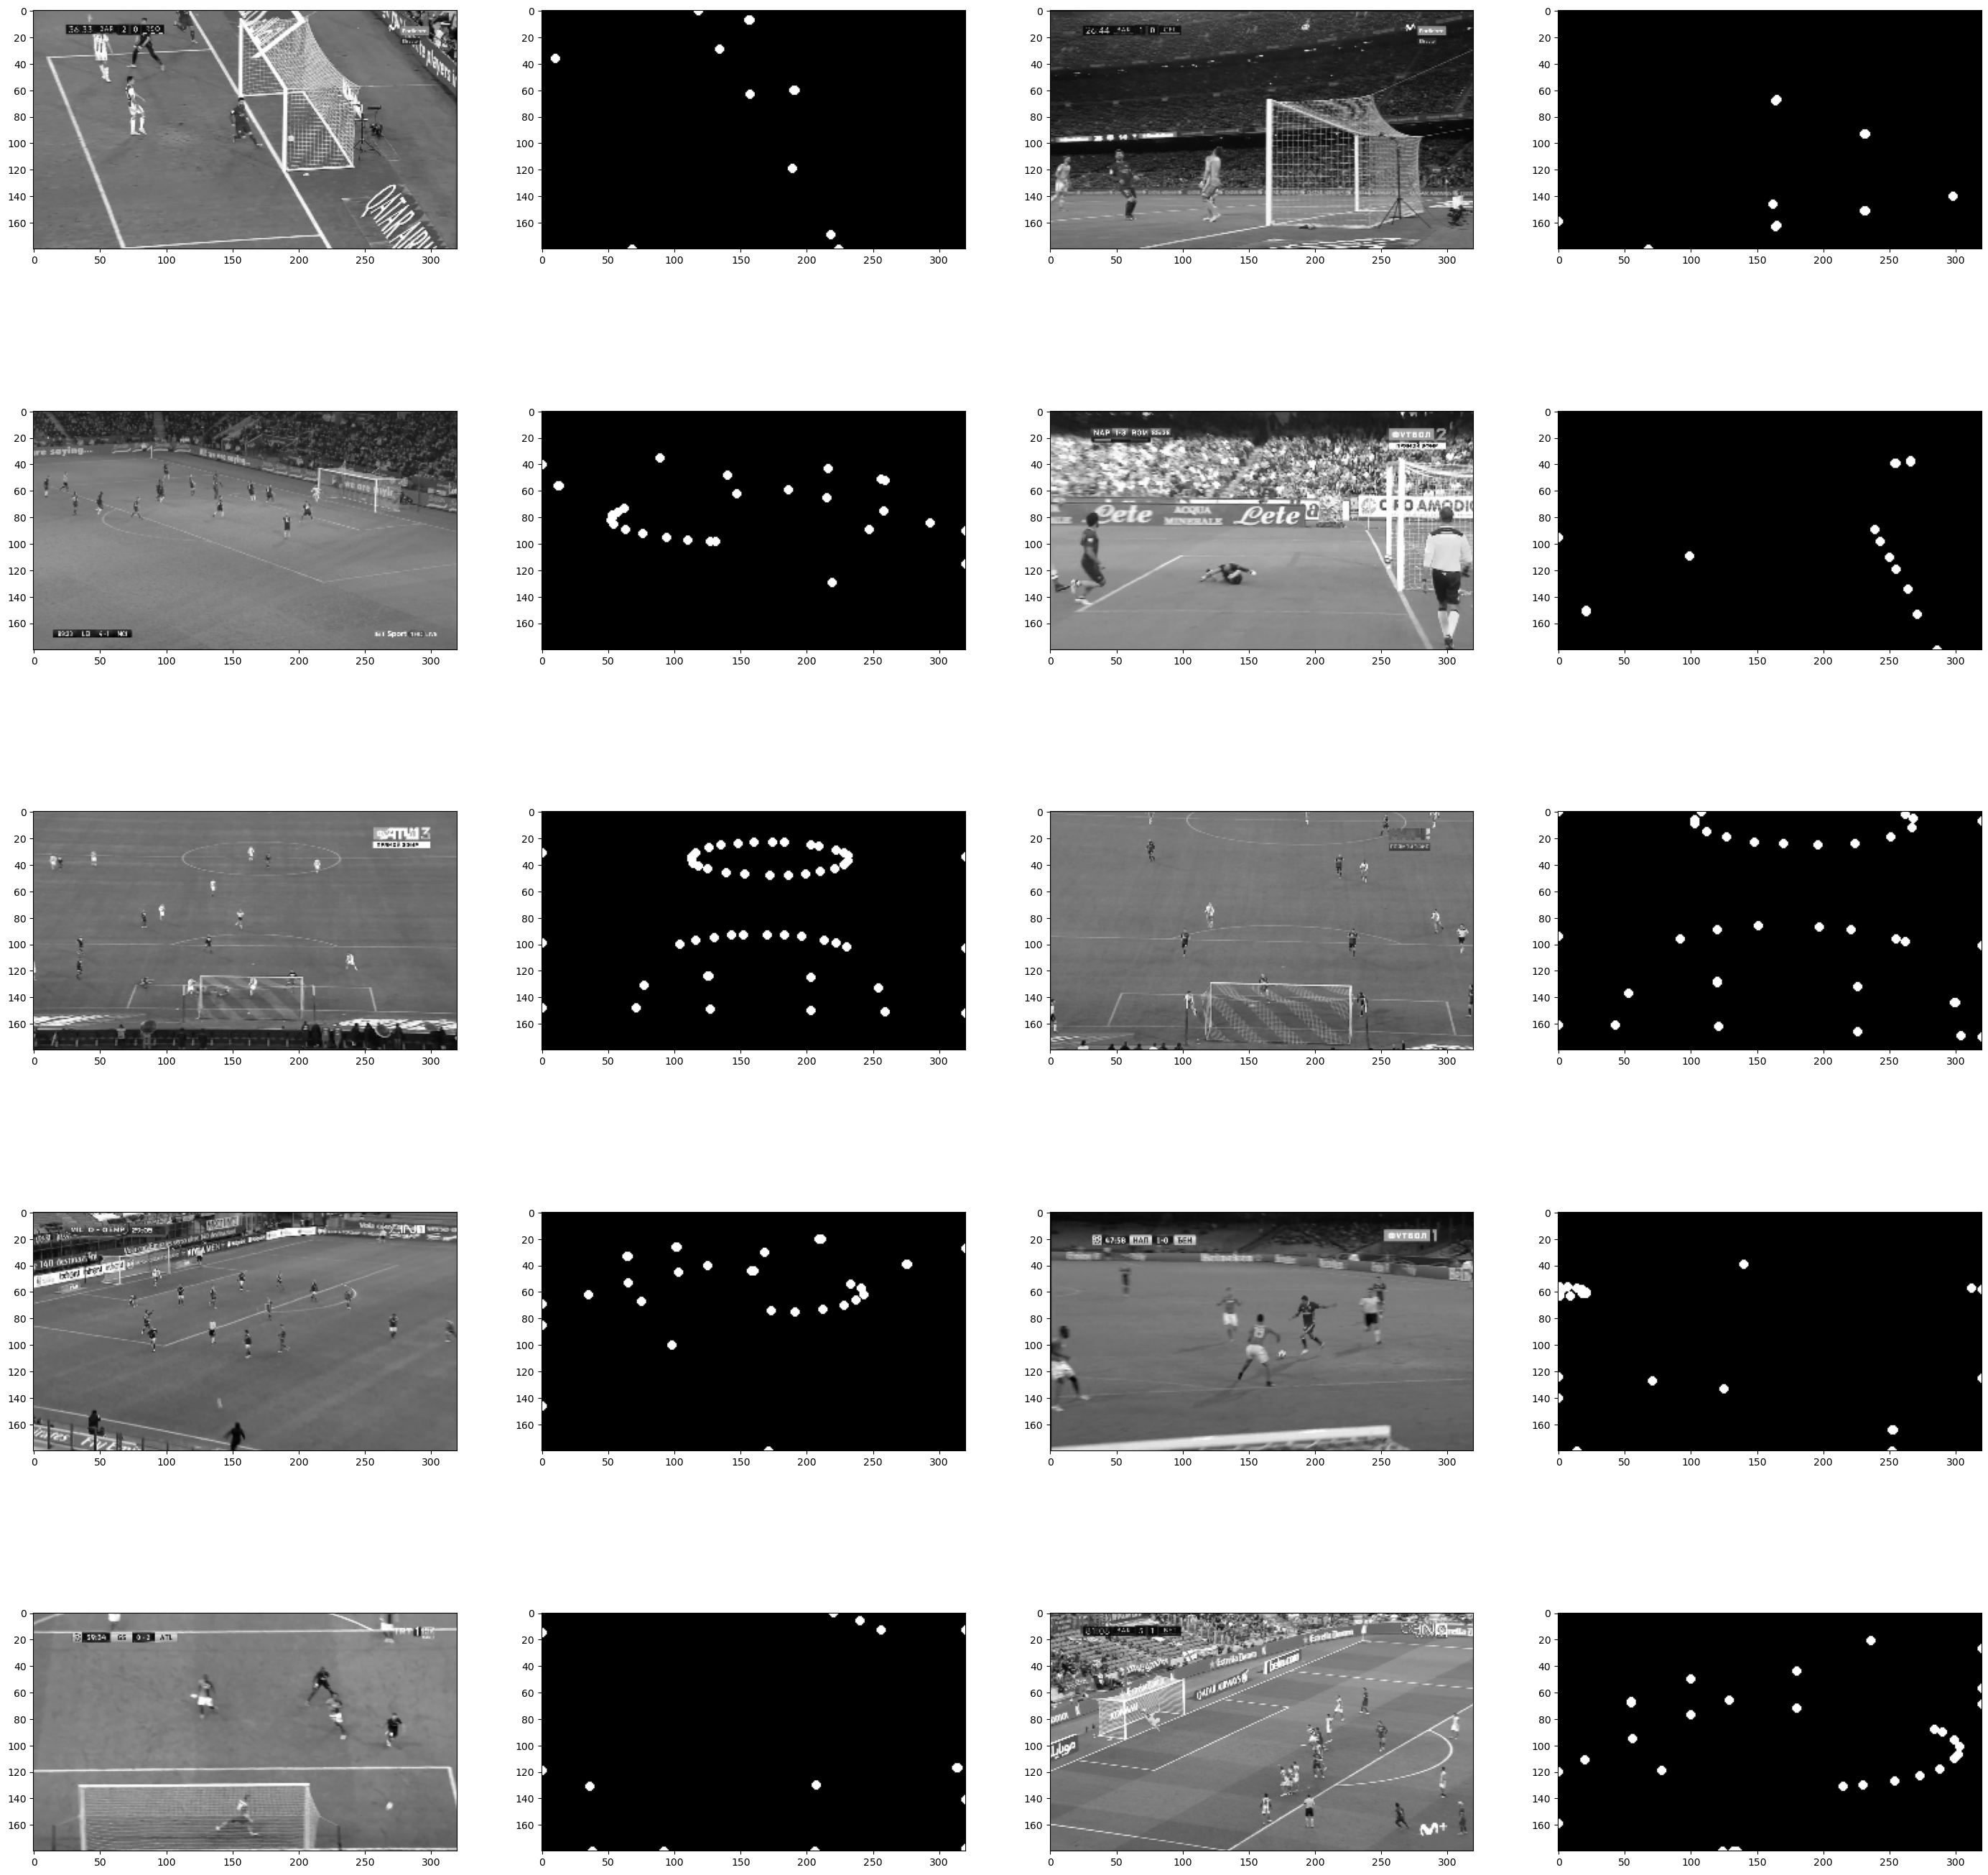

In [5]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, mask = masking_calibration_train_dataset[idx]
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [6]:
DEVICE = torch.device('cpu')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_seg_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_seg_model.eval()

print(f'UNet model device: {next(unet_seg_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_50024/1993563393.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this e

UNet model device: cpu


img.shape = torch.Size([4, 1, 180, 320]), out_mask.shape = torch.Size([4, 1, 180, 320]), mask.shape = torch.Size([4, 1, 180, 320])


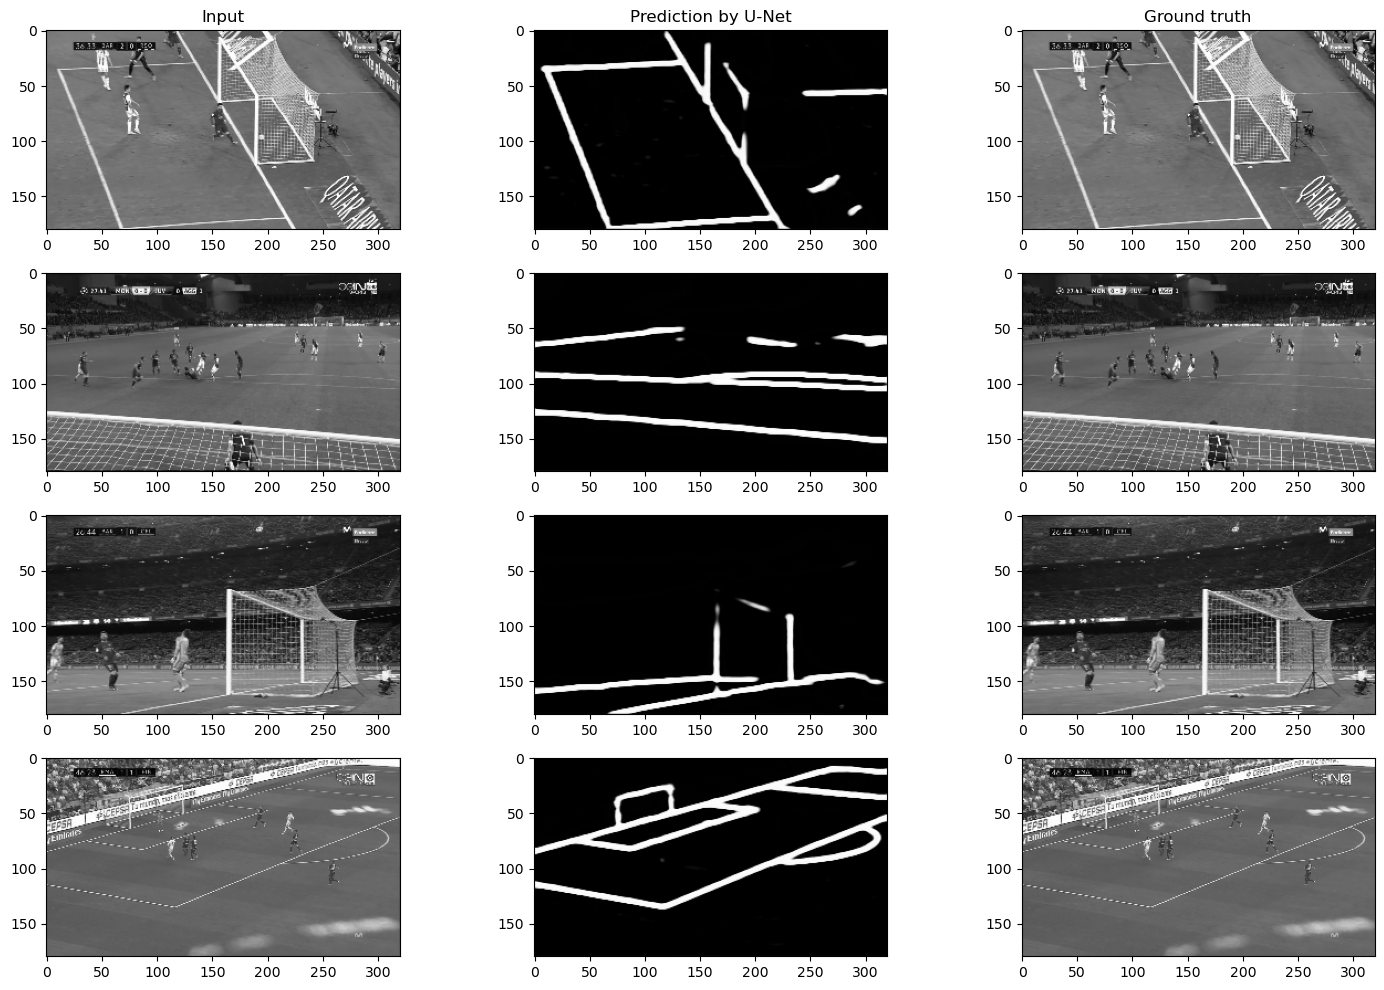

In [7]:
torch.mps.empty_cache()

batch_size = 4
valid_dataloader = DataLoader(masking_calibration_train_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(valid_dataloader))
img = img.float().unsqueeze(1).to(DEVICE)
mask = mask.float().unsqueeze(1).to(DEVICE)

unet_seg_model.eval()
out_mask = unet_seg_model(img)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img = img.to('cpu')
mask = img.to('cpu')

fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 10))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

#### Loss Functions (adapted from Multiple View Geometry in Computer Vision)

- $ \text{Algebraic loss} = \sum_{i} || \mathbf{x}'_i - H\mathbf{x}_i ||^2 = || A \mathbf{h} ||^2 $
- $ \text{Symmetric transfer error loss} = \sum_{i} (|| \mathbf{x}'_i - H\mathbf{x}_i ||^2 + || \mathbf{x}_i - H^{-1} \mathbf{x}_i' ||^2) $

In [8]:
class KeypointHeatmap(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
        self.eps = 1e-6

    def forward(self, x):
        # x: [N x 1 x H x W]
        x = self.unet(x)
        min_x = torch.amin(x, dim=(-1, -2), keepdim=True) 
        max_x = torch.amax(x, dim=(-1, -2), keepdim=True) 
        return (x - min_x + self.eps) / (max_x - min_x + self.eps)

In [12]:
# Choice of the loss function: https://arxiv.org/pdf/2312.05391
class DiceLoss(nn.Module):
    def __init__(self, k=0.001):
        super().__init__()
        self.k = k

    def forward(self, pred, target):
        pred_comp = 1 - pred
        target_comp = 1 - target
        dice_loss = 1 - (pred * target).sum() / (pred + target).sum() - (pred_comp * target_comp).sum() / (pred_comp + target_comp).sum()
        regulariser = torch.mean(F.sigmoid(pred))
        return dice_loss + self.k * regulariser

# class KeypointMaskLoss(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, homography, target_homography):
#         n_batch = homography.shape[0]
#         theta = homography.view(n_batch, -1)
#         target_theta = target_homography.view(n_batch, -1)

#         normalised_theta = theta / theta[:, -1].view(n_batch, -1)
#         normalised_target_theta = target_theta / target_theta[:, -1].view(n_batch, -1)
#         losses = torch.linalg.vector_norm(normalised_theta - normalised_target_theta, ord=2, dim=[1])
#         return losses.mean()
    

In [13]:
# https://medium.com/@weidagang/learning-pytorch-the-basic-program-structure-ed5723118b67

torch.mps.empty_cache()
DEVICE = torch.device('mps')

n_epochs = 32    # number of epochs to run
batch_size = 4   # size of each batch

train_dataloader = DataLoader(masking_calibration_train_dataset, batch_size=batch_size, shuffle=False)
valid_dataloader = DataLoader(masking_calibration_valid_dataset, batch_size=batch_size, shuffle=False)

unet_seg_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_seg_model.eval()

# unet_keypoint_model = KeypointHeatmap().to(DEVICE)
unet_keypoint_model = torch.load('../weights/experimental/251026-unet-keypoint-model.pt')
keypoint_loss_fn = DiceLoss().to(DEVICE)  # binary cross entropy
optimiser = optim.Adam(unet_keypoint_model.parameters(), lr=0.1)

train_losses, test_losses = [], []

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_50024/3538948954.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_seg_model = torch.load('../weights/expe

0it [00:00, ?it/s]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_50024/3622811413.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
32it [00:28,  1.11it/s]



Epoch: 1, Train Loss: 0.0507 



0it [00:00, ?it/s]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_50024/3622811413.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
32it [00:07,  4.23it/s]



Epoch: 1, Test Loss: 0.5119



32it [00:28,  1.14it/s]


...


Epoch: 31, Test Loss: 0.4178



32it [00:28,  1.11it/s]



Epoch: 32, Train Loss: 0.0435 



32it [00:07,  4.04it/s]



Epoch: 32, Test Loss: 0.4796



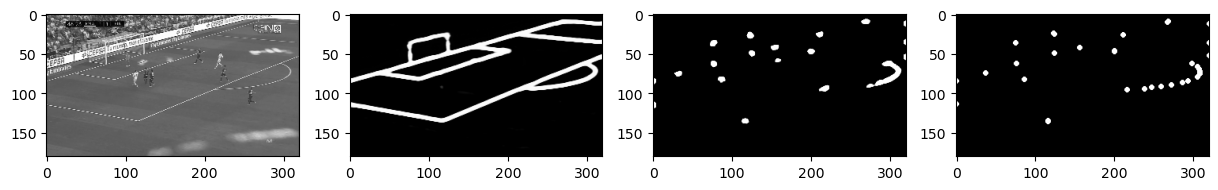

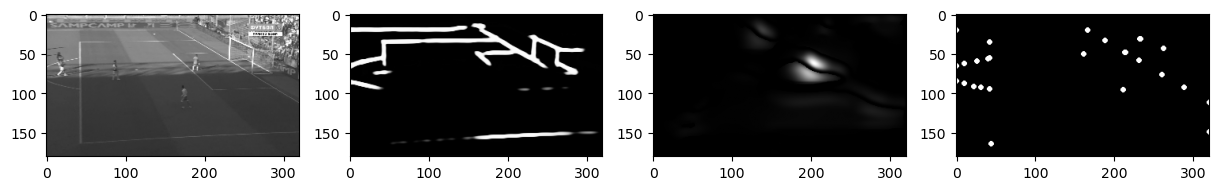

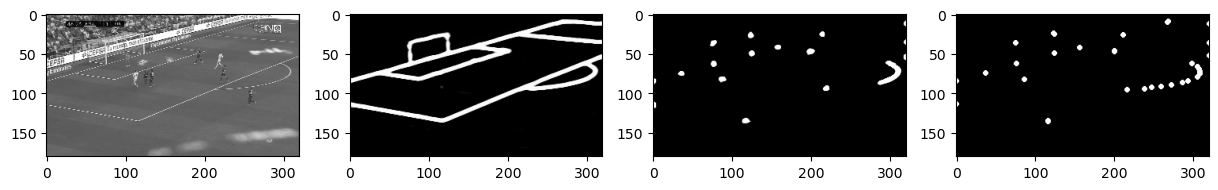

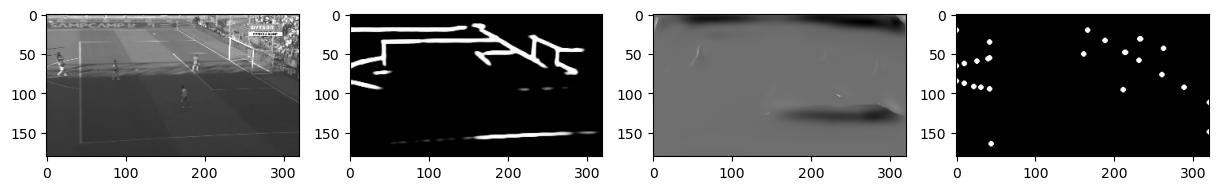

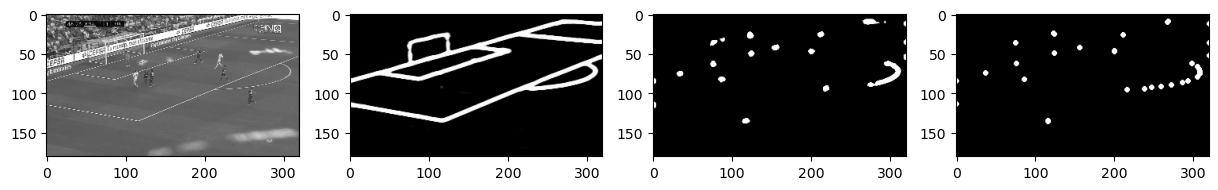

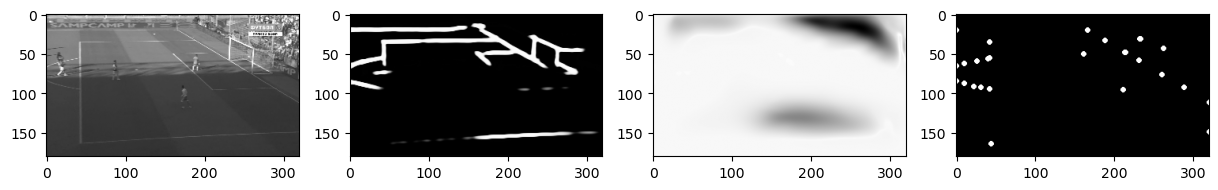

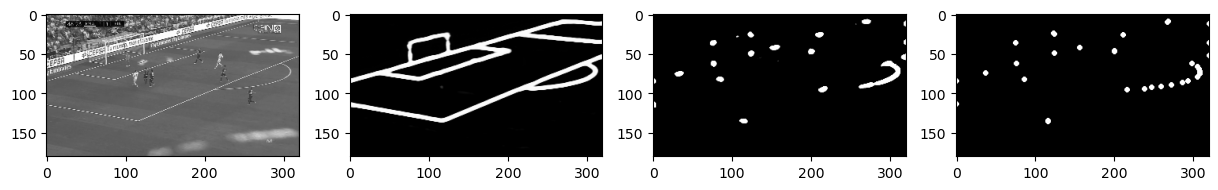

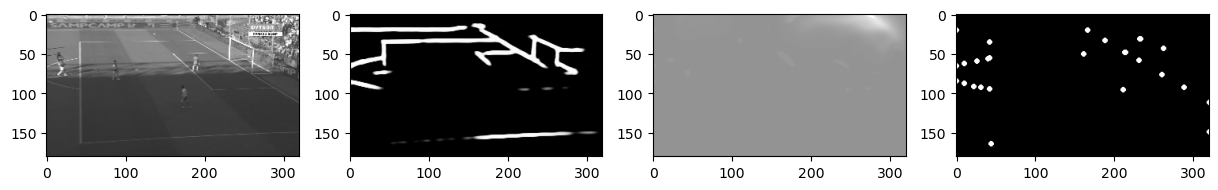

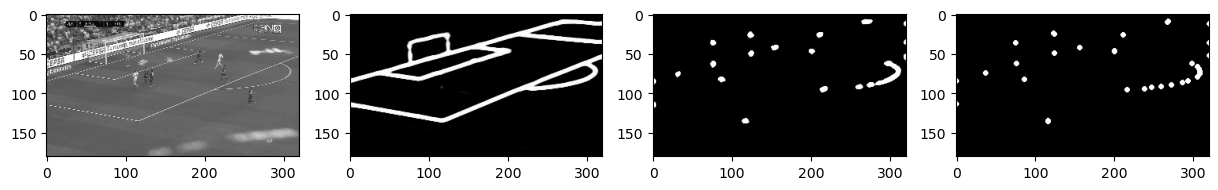

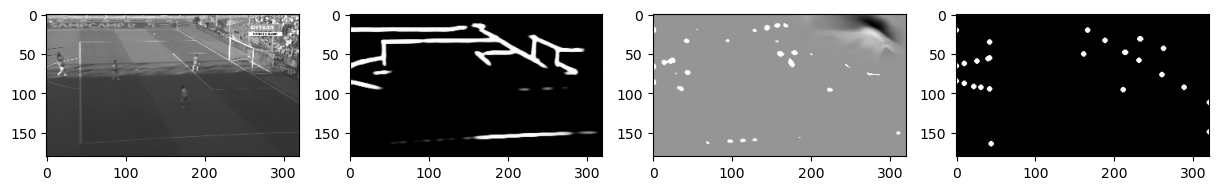

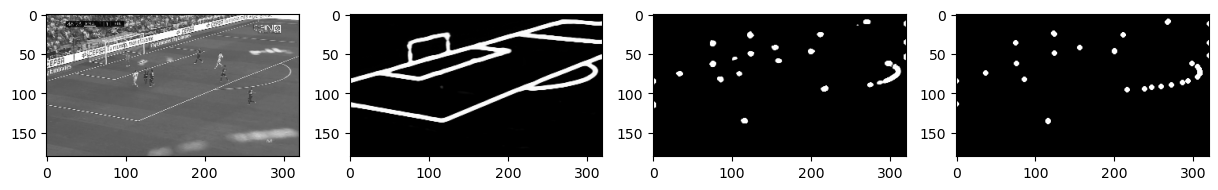

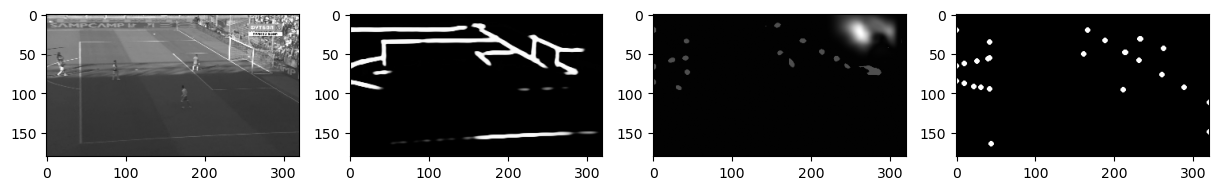

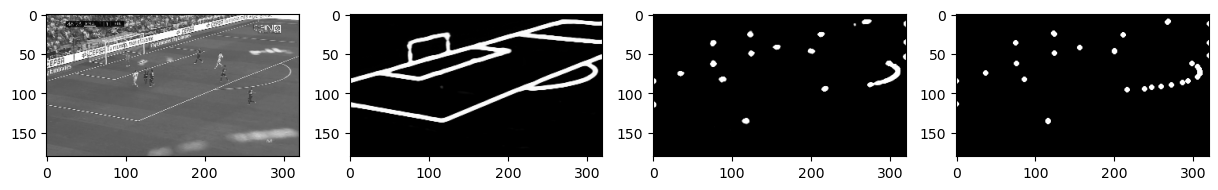

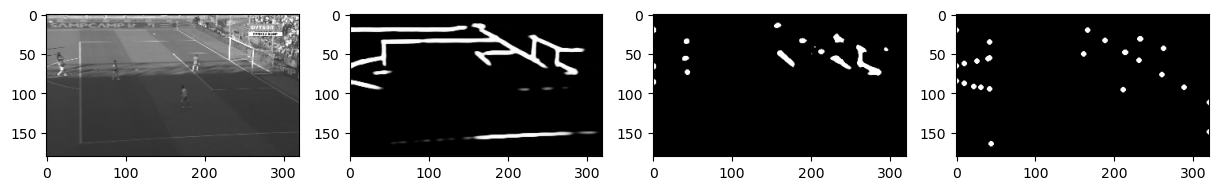

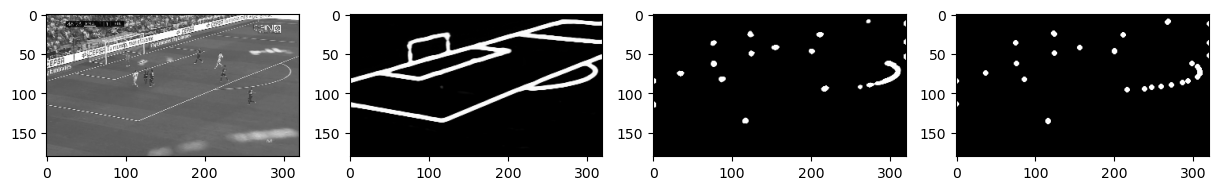

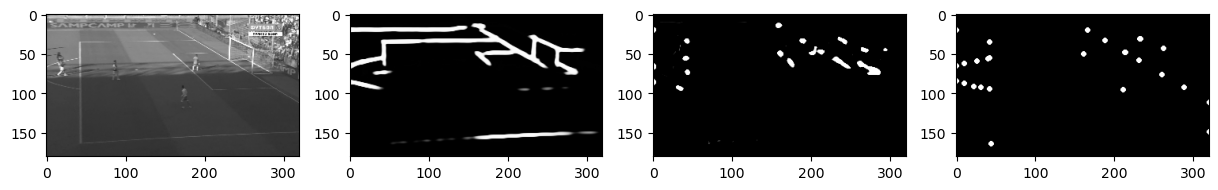

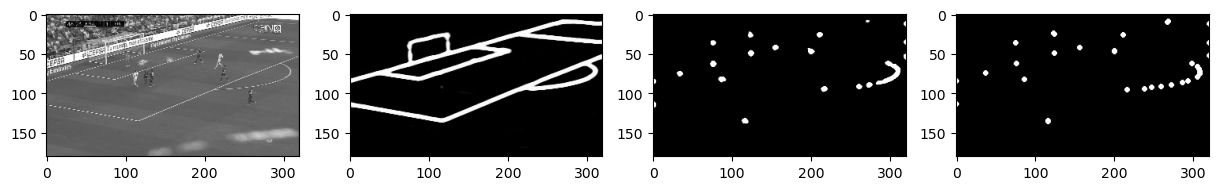

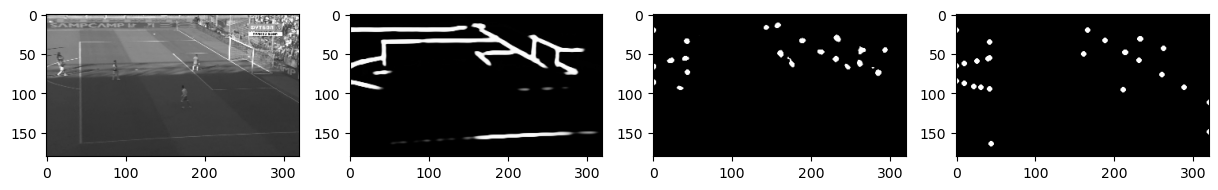

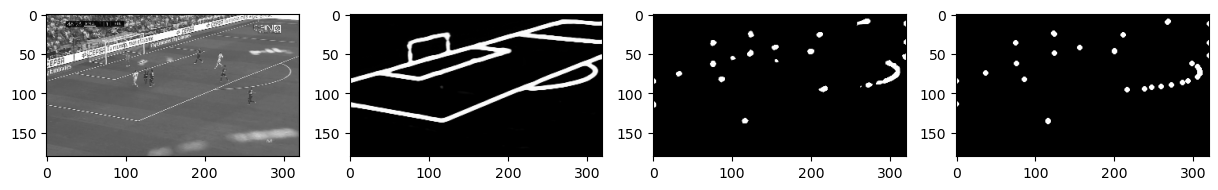

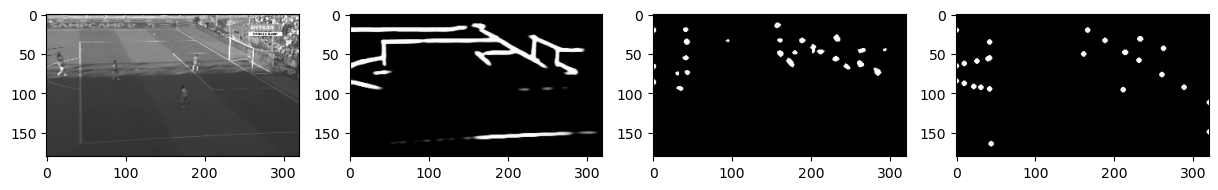

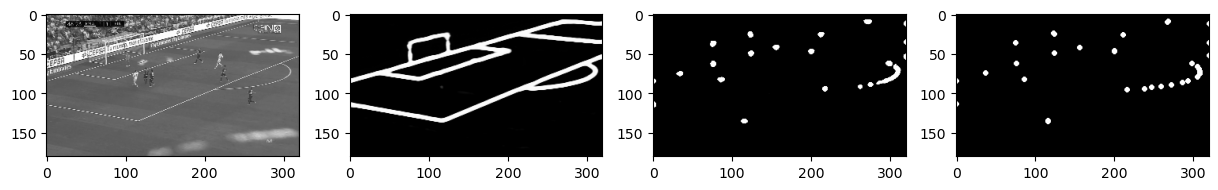

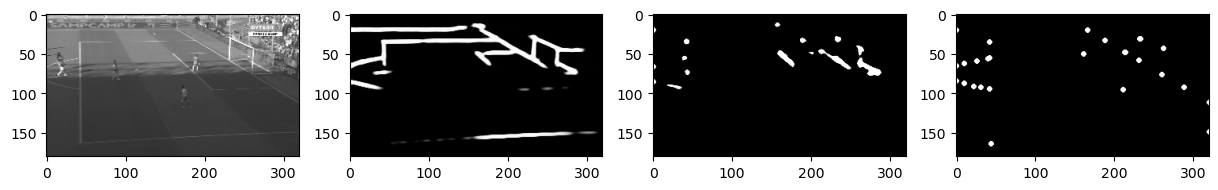

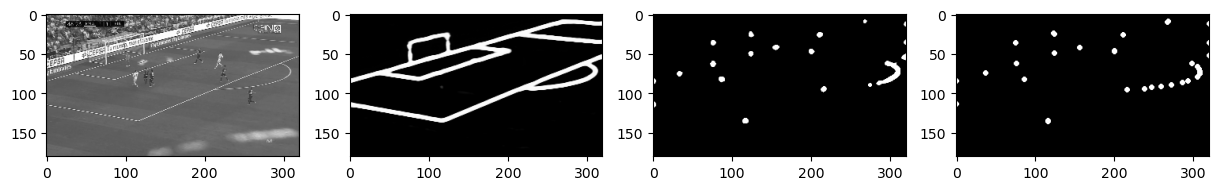

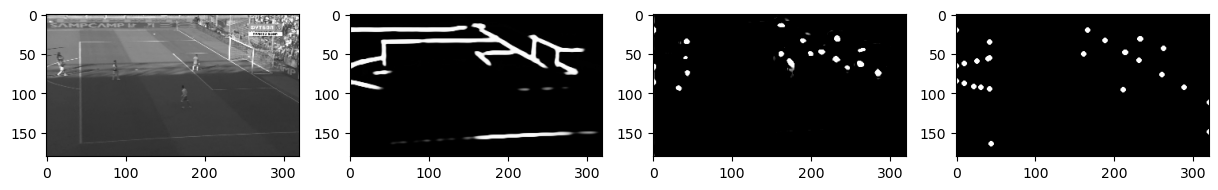

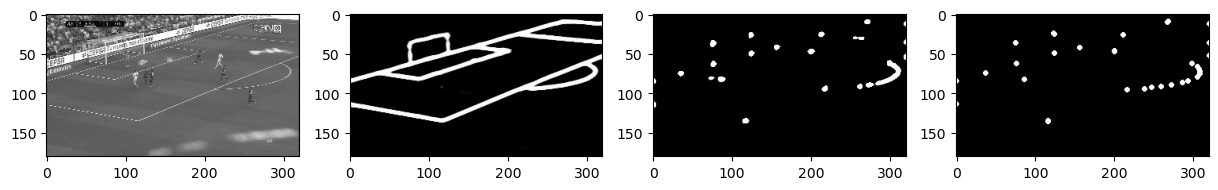

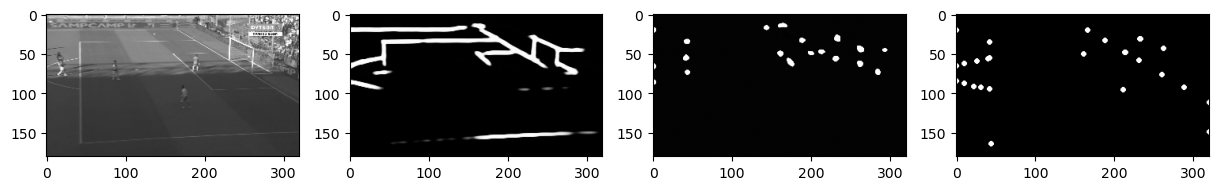

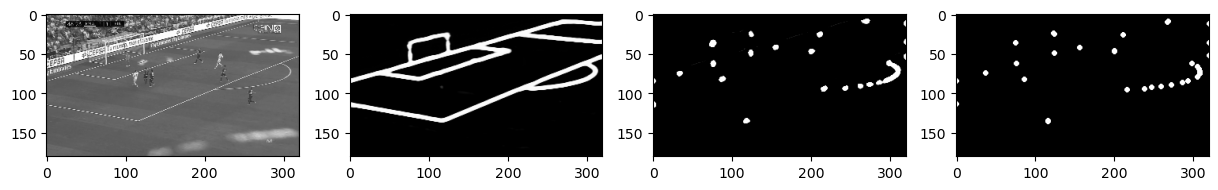

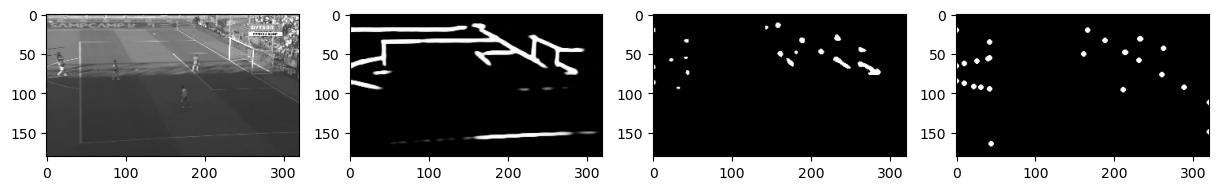

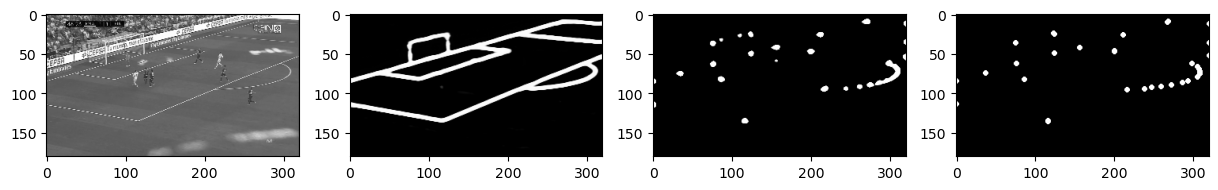

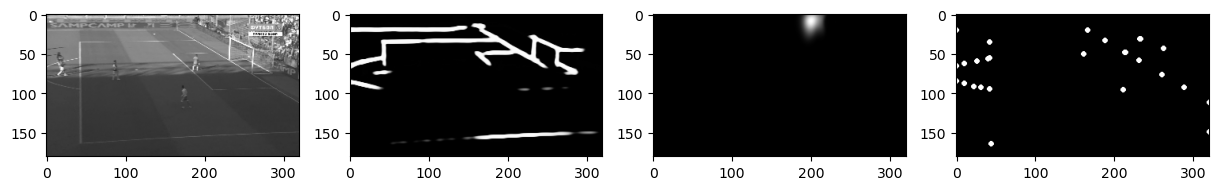

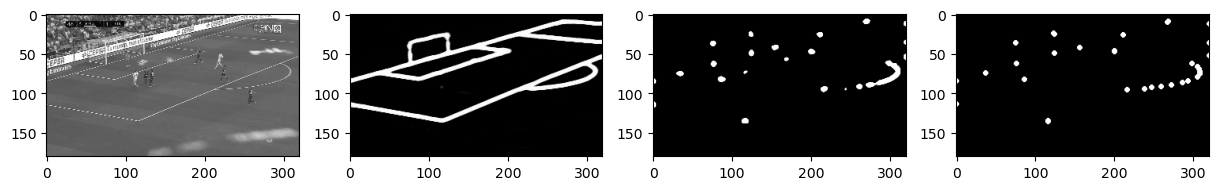

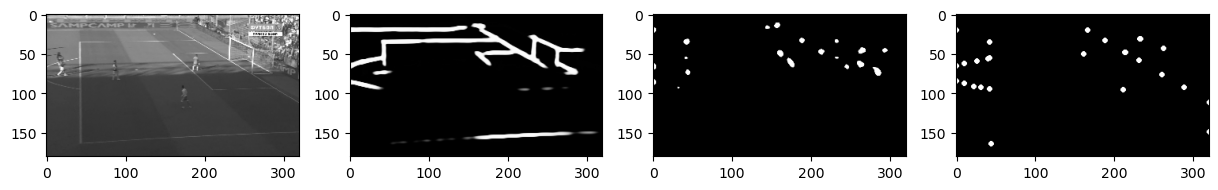

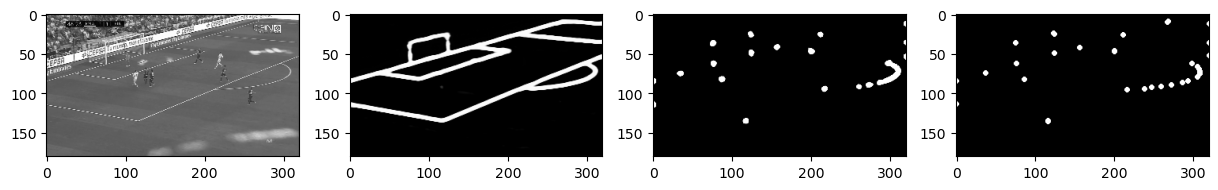

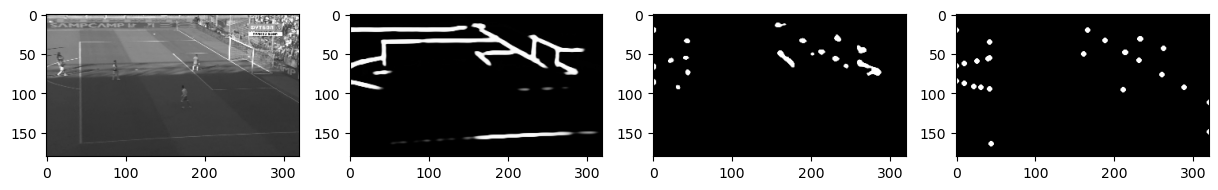

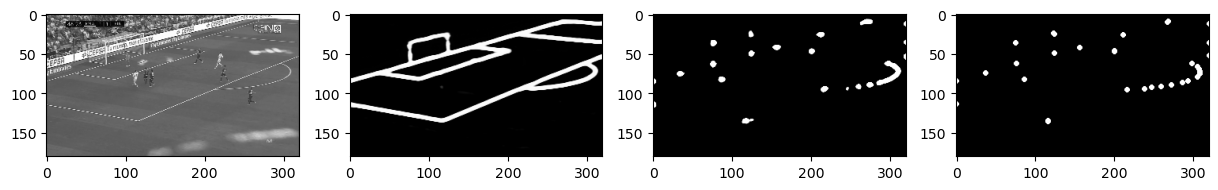

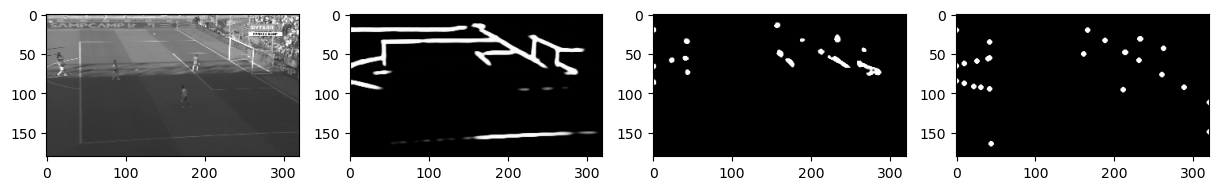

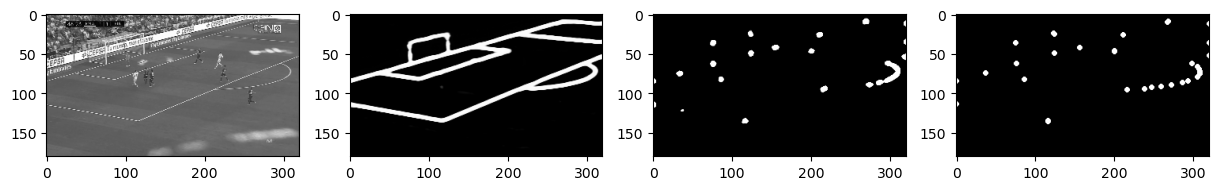

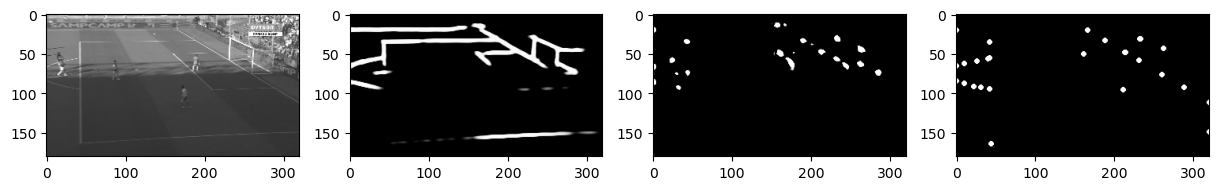

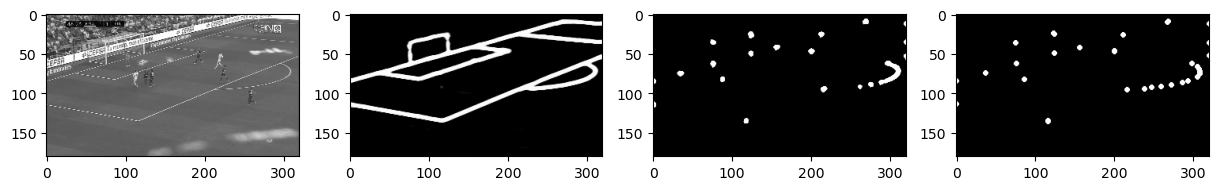

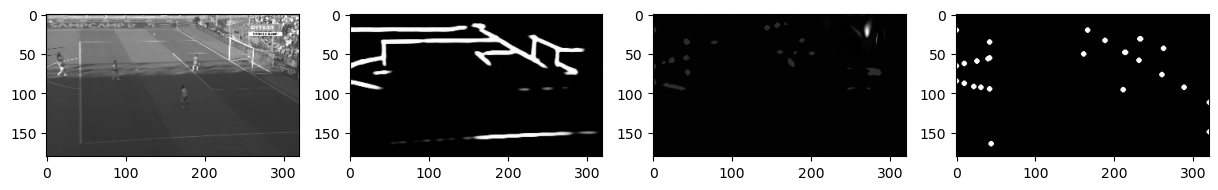

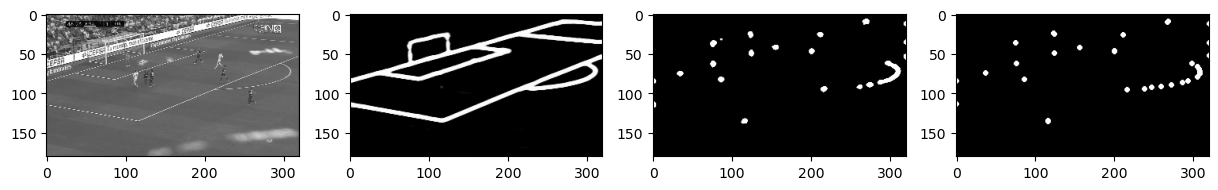

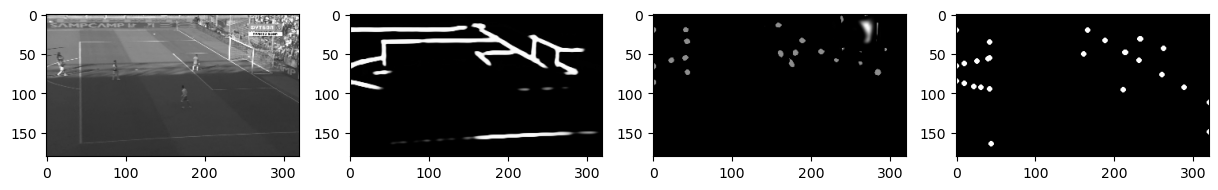

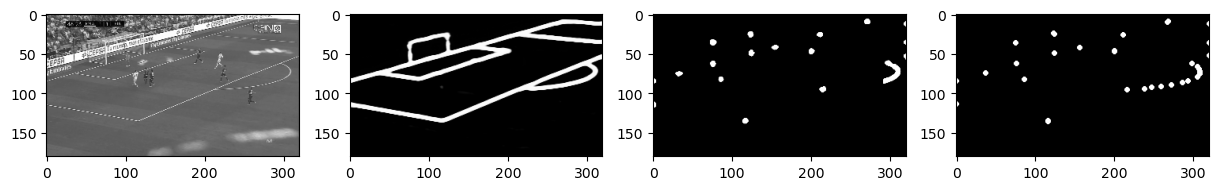

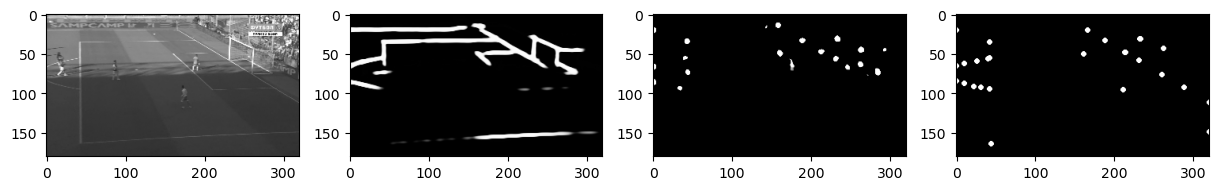

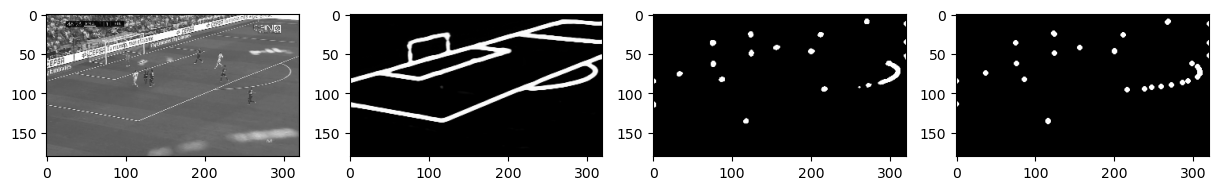

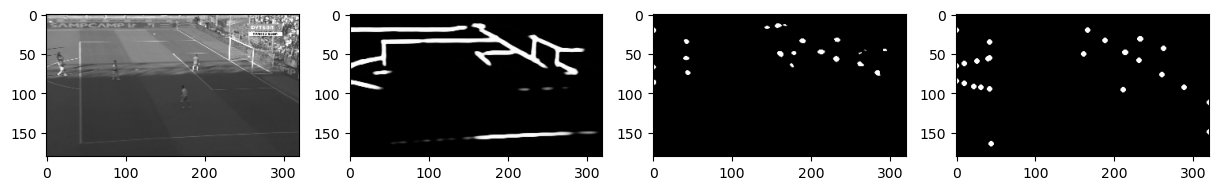

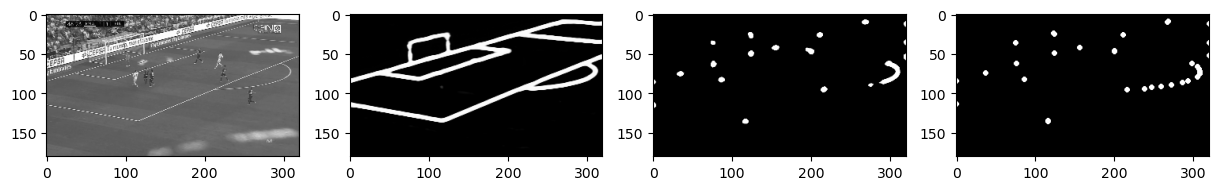

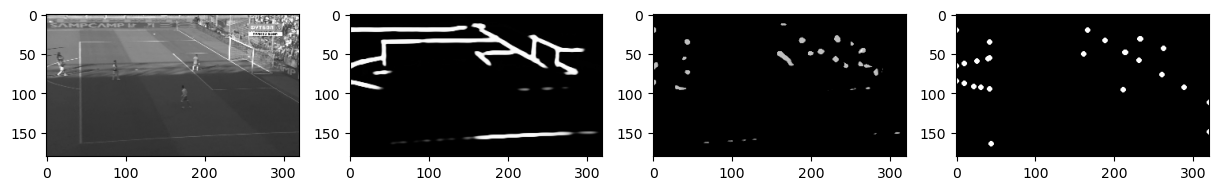

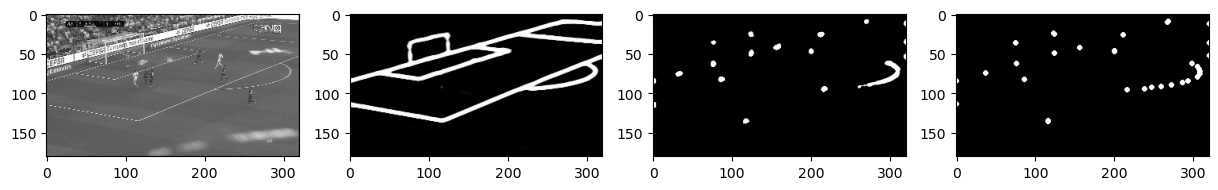

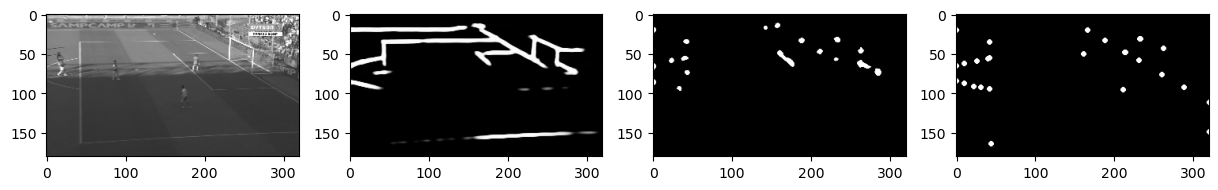

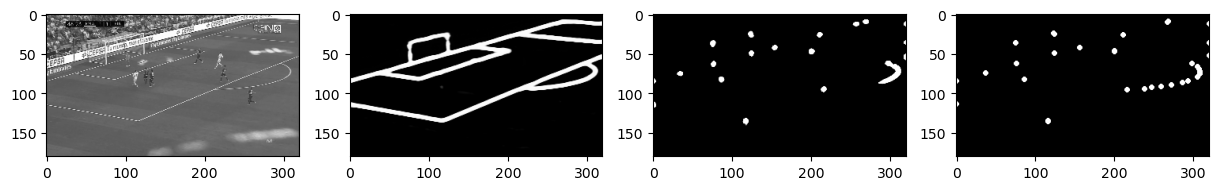

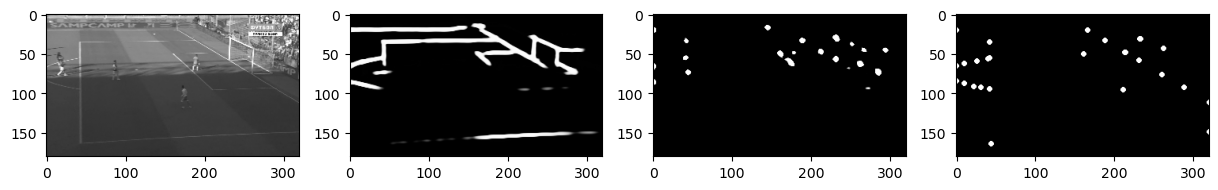

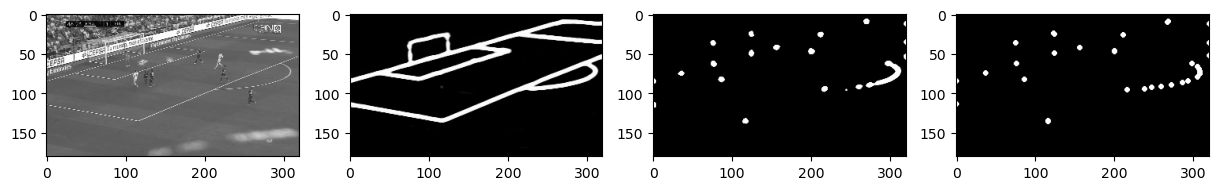

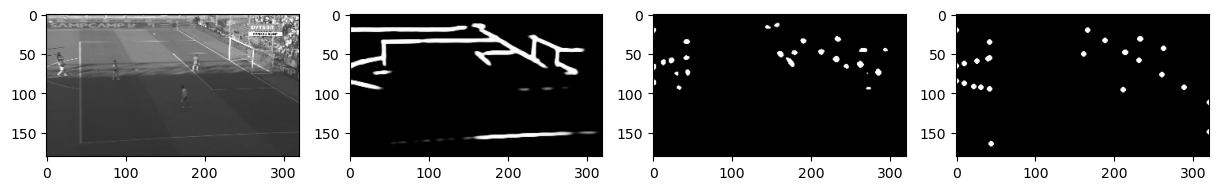

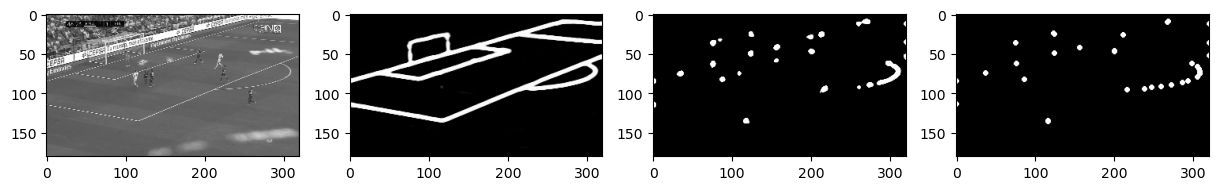

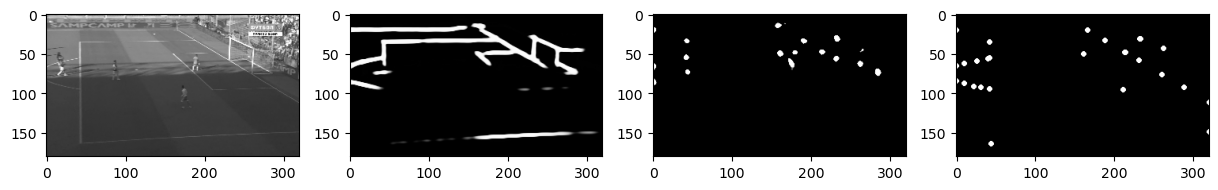

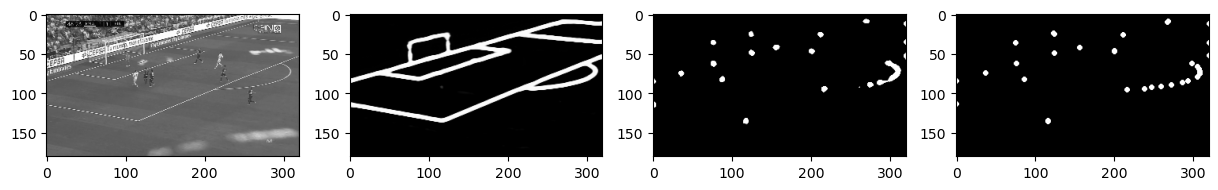

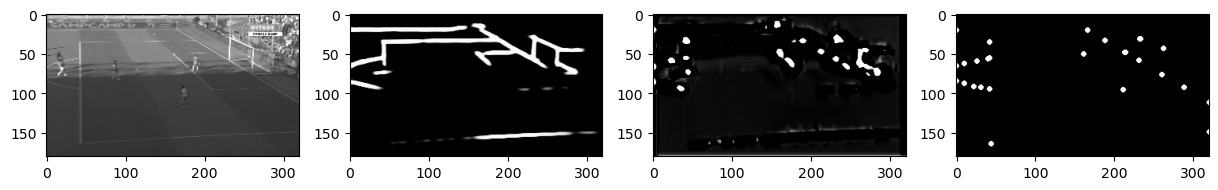

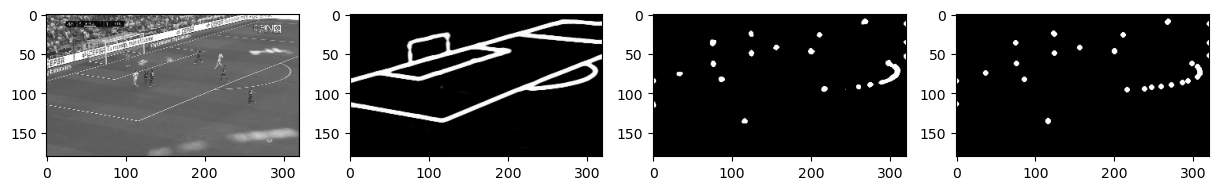

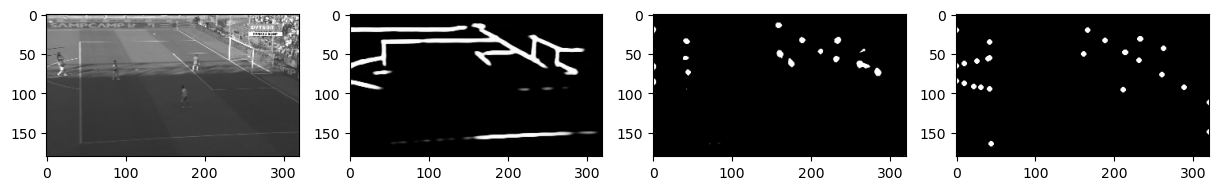

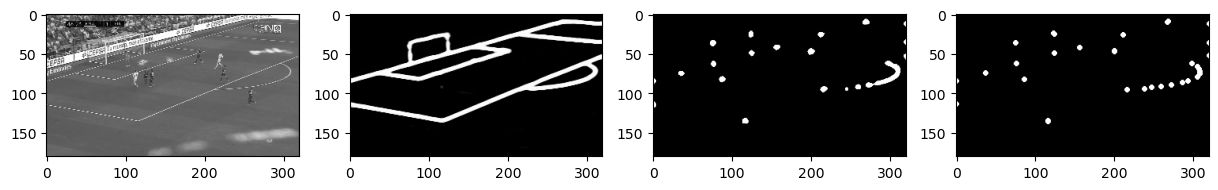

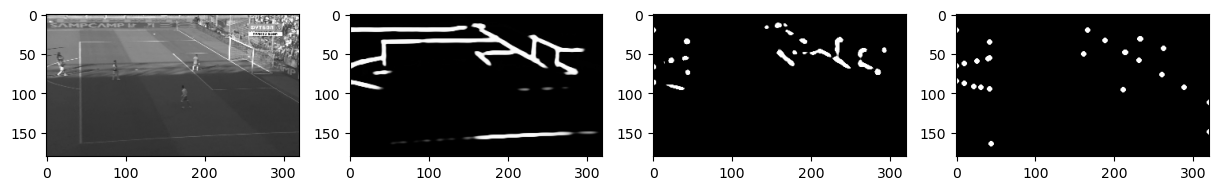

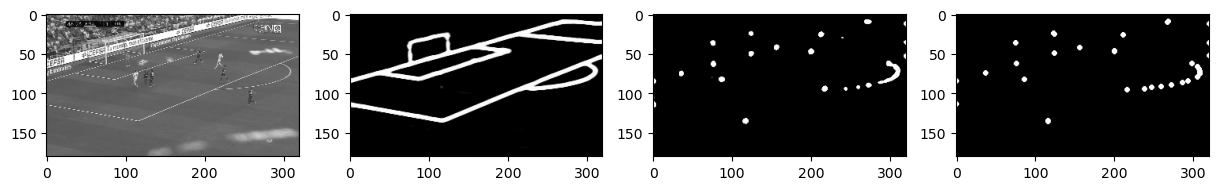

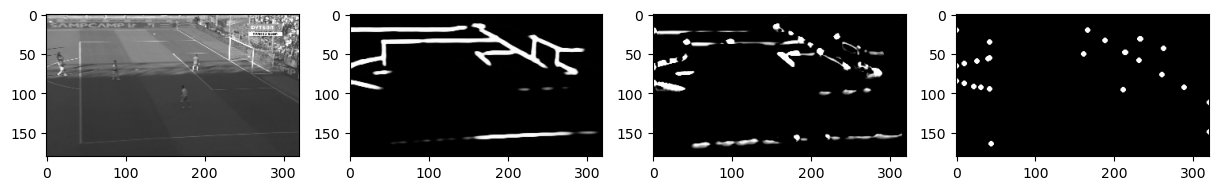

In [15]:
for epoch in range(n_epochs):                                       
    unet_keypoint_model.train()                                                  # Set the model to training mode

    train_loss = 0
    for batch_idx, (img, mask) in tqdm(enumerate(train_dataloader)):    # Iterate over batches of data
        # img:  [(N) x 180 (H) x 320 (W)]
        # mask: [(N) x 180 (H) x 320 (W)]

        img = img.float().unsqueeze(1).to(DEVICE)
        mask = mask.float().unsqueeze(1).to(DEVICE)

        optimiser.zero_grad()                                           # Clear gradients from the previous iteration
        seg_mask = unet_seg_model(img)
        out_mask = unet_keypoint_model(seg_mask)  

        # print(out_mask, torch.amin(out_mask, dim=(1, 2, 3)), torch.amax(out_mask, dim=(1, 2, 3)))
        # print(mask, torch.amin(mask, dim=(1, 2, 3)), torch.amax(mask, dim=(1, 2, 3)))
        # print(f'Loss: {keypoint_loss_fn(out_mask, mask).item()}')

        if batch_idx == 0:
            fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
            def img_convert(img):
                return img.permute((1, 2, 0)).detach().cpu().numpy()

            axes.flat[0].imshow(img_convert(img[3]), cmap='gray')
            axes.flat[1].imshow(img_convert(seg_mask[3]), cmap='gray')
            axes.flat[2].imshow(img_convert(out_mask[3]), cmap='gray')
            axes.flat[3].imshow(img_convert(mask[3]), cmap='gray')
            fig.show()

        loss = keypoint_loss_fn(out_mask, mask)                         # Calculate the loss
        train_loss += loss.item()

        loss.backward()                                                 # Compute gradients (backpropagation)
        optimiser.step()                                                # Update model parameters

    train_loss /= len(train_dataloader.dataset)
    train_losses.append(train_loss)
    print('\nEpoch: {}, Train Loss: {:.4f} \n'.format(epoch + 1, train_loss))

    unet_keypoint_model.eval()                                                   # Set the model to evaluation mode 
    test_loss = 0
    with torch.no_grad():                                               # Disable gradient calculations for efficiency
        for batch_idx, (img, mask) in tqdm(enumerate(valid_dataloader)): # Iterate over test data
            img = img.float().unsqueeze(1).to(DEVICE)
            mask = mask.float().unsqueeze(1).to(DEVICE)

            seg_mask = unet_seg_model(img)
            out_mask = unet_keypoint_model(seg_mask)  
            test_loss += keypoint_loss_fn(out_mask, mask).item() * len(img)      # Accumulate test loss 

            if batch_idx == 0:
                fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
                def img_convert(img):
                    return img.permute((1, 2, 0)).cpu().numpy()

                axes.flat[0].imshow(img_convert(img[3]), cmap='gray')
                axes.flat[1].imshow(img_convert(seg_mask[3]), cmap='gray')
                axes.flat[2].imshow(img_convert(out_mask[3]), cmap='gray')
                axes.flat[3].imshow(img_convert(mask[3]), cmap='gray')
                fig.show()

    test_loss /= len(valid_dataloader.dataset)                           # Calculate average test loss
    test_losses.append(test_loss)
    print('\nEpoch: {}, Test Loss: {:.4f}\n'.format(epoch + 1, test_loss))

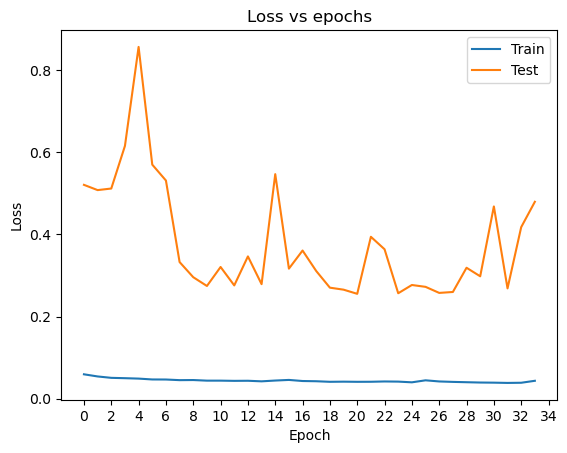

In [16]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.legend(labels=['Train', 'Test'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(test_losses) + 1, len(test_losses) // 16))
plt.title('Loss vs epochs')
plt.show()

In [17]:
torch.save(unet_keypoint_model, '../weights/experimental/251102-unet-keypoint-model.pt')